In [1]:
import pandas as pd

In [2]:
df = pd.read_csv(r"C:\Users\sekar\Desktop\retail_sales\Dataset\retail_business_table.csv")

In [3]:
df.head()

,transactionid,date,customerid,gender,birthdate,customer_city,joindate,productid,productname,category,...,costprice,storeid,storename,region,quantity,discount,paymentmethod,revenue,cost,profit
0,T00001,2024-06-18,C160,M,1991-09-10,Port Jacob,2021-10-27,P014,Add Clothing,Fashion,...,797.94,S003,MegaMart New Michele,West,1,0.10,Bank Transfer,1208.475,797.94,410.535
1,T00002,2023-11-02,C171,M,1993-03-15,Robertsborough,2025-07-28,P030,National Watches,Fashion,...,15.28,S004,MegaMart Brianahaven,North,3,0.15,Bank Transfer,74.562,45.84,28.722
2,T00003,2024-03-28,C142,M,2005-07-25,Joelborough,2020-12-27,P002,Audience Television,Electronics,...,527.62,S002,MegaMart Peckmouth,East,2,0.15,Mobile Money,1391.892,1055.24,336.652
3,T00004,2024-06-15,C174,M,2005-07-07,South Jennifer,2025-08-28,P050,Maybe Footwear,Fashion,...,775.07,S002,MegaMart Peckmouth,East,5,0.10,Mobile Money,4700.880,3875.35,825.530
4,T00005,2024-08-29,C141,F,1978-08-06,Allisonmouth,2024-01-07,P036,New Watches,Fashion,...,1167.73,S001,MegaMart Jimenezborough,South,3,0.10,Credit Card,4053.942,3503.19,550.752


In [4]:
df.shape

(5000, 22)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   transactionid  5000 non-null   object 
 1   date           5000 non-null   object 
 2   customerid     5000 non-null   object 
 3   gender         5000 non-null   object 
 4   birthdate      5000 non-null   object 
 5   customer_city  5000 non-null   object 
 6   joindate       5000 non-null   object 
 7   productid      5000 non-null   object 
 8   productname    5000 non-null   object 
 9   category       5000 non-null   object 
 10  subcategory    5000 non-null   object 
 11  unitprice      5000 non-null   float64
 12  costprice      5000 non-null   float64
 13  storeid        5000 non-null   object 
 14  storename      5000 non-null   object 
 15  region         5000 non-null   object 
 16  quantity       5000 non-null   int64  
 17  discount       5000 non-null   float64
 18  paymentm

In [6]:
df.isnull().sum()

transactionid    0
date             0
customerid       0
gender           0
birthdate        0
customer_city    0
joindate         0
productid        0
productname      0
category         0
subcategory      0
unitprice        0
costprice        0
storeid          0
storename        0
region           0
quantity         0
discount         0
paymentmethod    0
revenue          0
cost             0
profit           0
dtype: int64

In [7]:
df.duplicated().sum()

0

In [8]:
df[['revenue','cost','profit']].describe()

,revenue,cost,profit
count,5000.000000,5000.000000,5000.000000
mean,2860.380629,2095.117696,765.262934
std,2265.958863,1717.600926,711.175525
min,21.734500,15.280000,2.684500
25%,1043.154000,738.210000,248.907875
50%,2156.120000,1582.860000,555.111000
75%,4451.305500,3191.760000,1066.502000
max,9763.250000,7256.350000,4372.600000


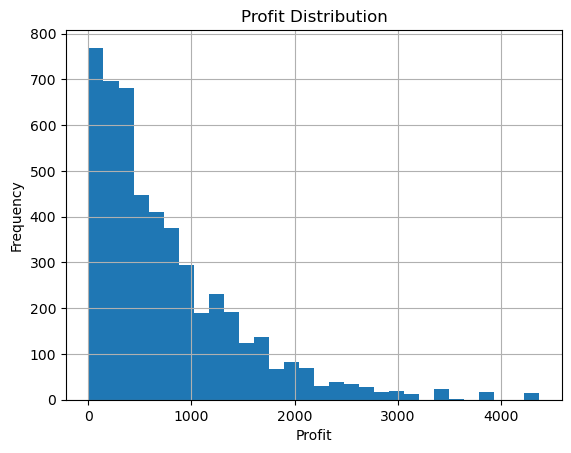

In [9]:
import matplotlib.pyplot as plt

df['profit'].hist(bins = 30)

plt.title("Profit Distribution")
plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.show()

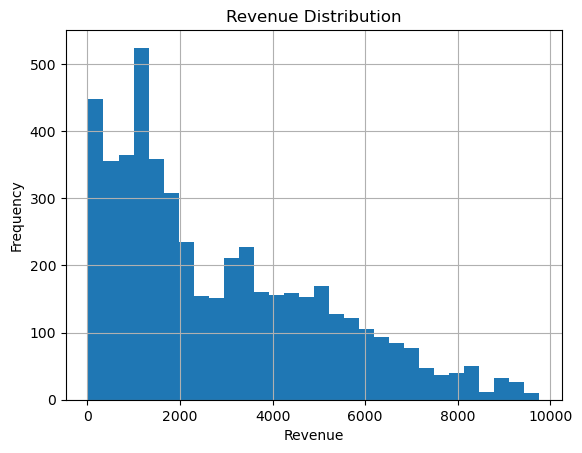

In [10]:
df['revenue'].hist(bins=30)

plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.show()

In [11]:
corr = df[['quantity','discount','revenue','cost','profit']].corr()

corr

,quantity,discount,revenue,cost,profit
quantity,1.000000,-0.002085,0.596828,0.572389,0.519216
discount,-0.002085,1.000000,-0.078230,-0.003273,-0.241351
revenue,0.596828,-0.078230,1.000000,0.973654,0.834687
cost,0.572389,-0.003273,0.973654,1.000000,0.687116
profit,0.519216,-0.241351,0.834687,0.687116,1.000000


In [12]:
import seaborn as sns

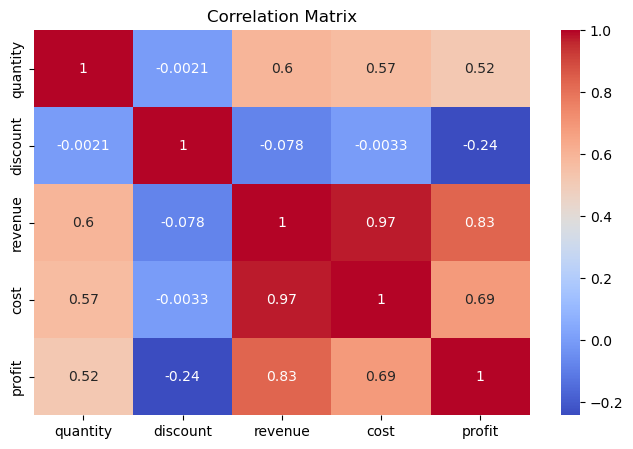

In [13]:
plt.figure(figsize=(8,5))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')
plt.show()

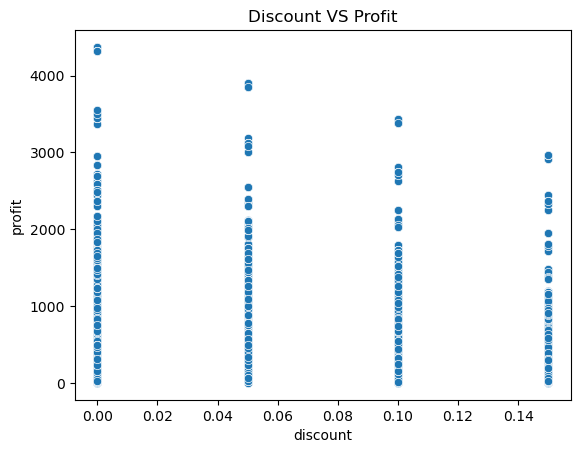

In [14]:
sns.scatterplot(
    data=df,
    x='discount',
    y='profit'
)

plt.title('Discount VS Profit')
plt.show()

In [15]:
category_summary = df.groupby('category').agg({
    'revenue':'sum',
    'profit':'sum',
    'quantity':'sum'
}).sort_values('profit',ascending=False)

category_summary

,revenue,profit,quantity
category,,,
Fashion,6.232280e+06,1.660525e+06,7015
Electronics,6.316917e+06,1.632229e+06,5431
Groceries,1.752706e+06,5.335605e+05,2503


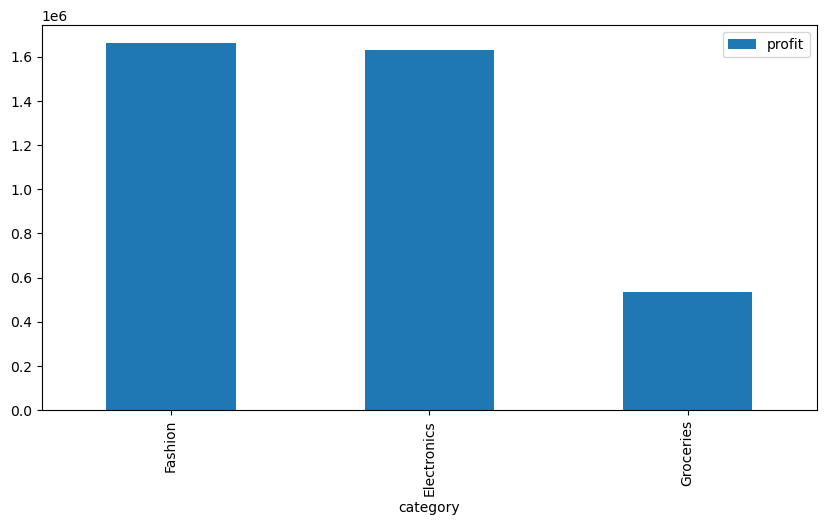

In [16]:
category_summary.plot(
    kind='bar',
    y='profit',
    figsize=(10,5)
)
plt.show()

In [17]:
region_summary = df.groupby('region').agg({
    'revenue':'sum',
    'profit':'sum',
    'quantity':'sum'
}).sort_values('revenue',ascending=False)

region_summary

,revenue,profit,quantity
region,,,
East,5.600680e+06,1.498459e+06,5834
West,2.920407e+06,8.040115e+05,3036
North,2.900701e+06,7.699833e+05,3018
South,2.880115e+06,7.538609e+05,3061


In [18]:
region_summary['avg_order_value'] = (
    df.groupby('region')['revenue'].mean()
)

region_summary

,revenue,profit,quantity,avg_order_value
region,,,,
East,5.600680e+06,1.498459e+06,5834,2854.577173
West,2.920407e+06,8.040115e+05,3036,2882.928855
North,2.900701e+06,7.699833e+05,3018,2869.140532
South,2.880115e+06,7.538609e+05,3061,2840.349828


In [19]:
product_summary = df.groupby('productname').agg({
    'revenue':'sum',
    'profit':'sum',
    'quantity':'sum'
}).sort_values('profit',ascending=False)

product_summary.head(10)

,revenue,profit,quantity
productname,,,
And Footwear,585613.0225,244603.2625,336
Set Dairy,573777.0780,242272.2780,330
Him Smartphone,431274.5295,172718.2695,318
Present Television,477913.4230,147190.4930,317
Understand Camera,333519.6500,146334.7500,245
Add Clothing,394835.6375,140292.7775,319
Road Clothing,479596.8975,137641.6375,346
World Watches,350085.8000,123927.3000,335
Book Television,605028.6025,115950.6125,337


In [20]:
discount_analysis = df.groupby('category').agg({
    'discount':'mean',
    'revenue':'sum',
    'profit':'sum',
    'quantity':'sum'
}).sort_values('discount',ascending=False)

discount_analysis

,discount,revenue,profit,quantity
category,,,,
Groceries,0.076978,1.752706e+06,5.335605e+05,2503
Electronics,0.076291,6.316917e+06,1.632229e+06,5431
Fashion,0.075180,6.232280e+06,1.660525e+06,7015


In [21]:
df['profit_margin'] = (
    df['profit'] / df['revenue']) * 100

In [22]:
margin_analysis = df.groupby('category').agg({
    'profit_margin':'mean',
    'unitprice':'mean',
    'cost':'mean',
    'quantity':'sum',
    'revenue':'sum',
    'profit':'sum'
}).sort_values('profit_margin',ascending=False)

margin_analysis

,profit_margin,unitprice,cost,quantity,revenue,profit
category,,,,,,
Groceries,29.296207,770.306882,1461.805228,2503,1.752706e+06,5.335605e+05
Fashion,28.077049,961.061569,1933.088609,7015,6.232280e+06,1.660525e+06
Electronics,26.729591,1259.126119,2601.159556,5431,6.316917e+06,1.632229e+06


In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [24]:
model = LinearRegression()

In [25]:
x = df[['cost','quantity','discount']]
y = df['revenue']

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size = 0.2,
    random_state = 42
)

In [27]:
scaler = StandardScaler()

In [28]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [29]:
model.fit(X_train,y_train)

LinearRegression()

In [30]:
y_pred = model.predict(X_test)

In [31]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

In [32]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE : ",mae)
print("MSE : " ,mse)
print("RMSE : ",rmse)
print("R2 Score : ",r2)

MAE :  331.3311636292385
MSE :  229002.956502444
RMSE :  478.5425336398469
R2 Score :  0.9566877944229791


In [33]:
coef = pd.DataFrame({
    'Feature': x.columns,
    'Coefficient': model.coef_
})
print(coef)

    Feature  Coefficient
0      cost  2120.170981
1  quantity   133.266527
2  discount  -168.990318


In [34]:
print("Intercept:", model.intercept_)

Intercept: 2838.800302375


In [35]:
new_data = [[1500, 5, 0.10]]

new_data_scaled = scaler.transform(new_data)

prediction = model.predict(new_data_scaled)

print("Predicted Revenue:", prediction[0])

Predicted Revenue: 2239.181604771238


C:\Users\sekar\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [36]:
import statsmodels.api as sm

X = df[['cost', 'quantity', 'discount']]
y = df['revenue']

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                revenue   R-squared:                       0.956
Model:                            OLS   Adj. R-squared:                  0.956
Method:                 Least Squares   F-statistic:                 3.614e+04
Date:                Mon, 13 Jul 2026   Prob (F-statistic):               0.00
Time:                        13:08:01   Log-Likelihood:                -37917.
No. Observations:                5000   AIC:                         7.584e+04
Df Residuals:                    4996   BIC:                         7.587e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        208.7673     18.197     11.472      0.0

In [37]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df[['cost', 'quantity', 'discount']]

vif = pd.DataFrame()
vif['Feature'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i)
              for i in range(X.shape[1])]

print(vif)

    Feature       VIF
0      cost  3.700594
1  quantity  4.811392
2  discount  2.108205


In [120]:
x = df[['discount','category','region']]
y = df['revenue']

In [122]:
x = pd.get_dummies(
    x,
    columns = ['category', 'region'],
    drop_first = True
)

In [124]:
X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size = 0.2,
    random_state = 42
)

In [126]:
model = LinearRegression()

In [128]:
model.fit(X_train,y_train)

LinearRegression()